In [1]:
from PIL import Image  #used to open and processing image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
#step1:load the image
img=Image.open("download.jpg")

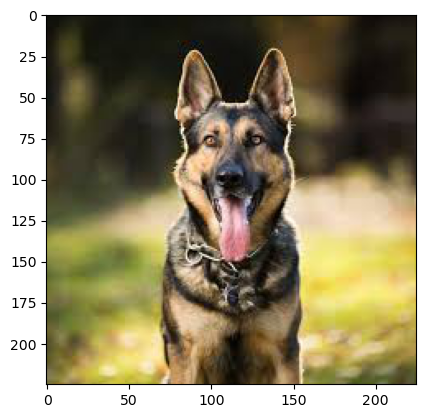

In [7]:
plt.imshow(img)

In [8]:
print("Original Image Size:",img.size)

Original Image Size: (225, 225)


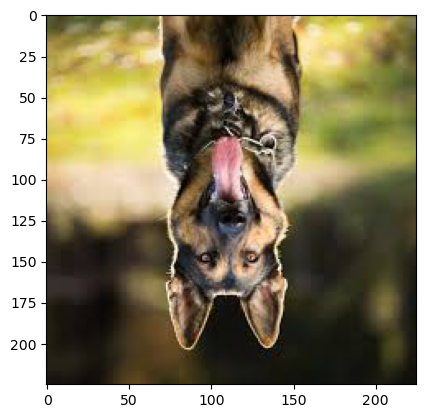

In [12]:
img_rotate_45=img.rotate(180)
plt.imshow(img_rotate_45)

In [13]:
#step2 Basic Preprocessing
processed=img.convert("RGB").resize((224,224)) #224x224 is a standard size is used in many 

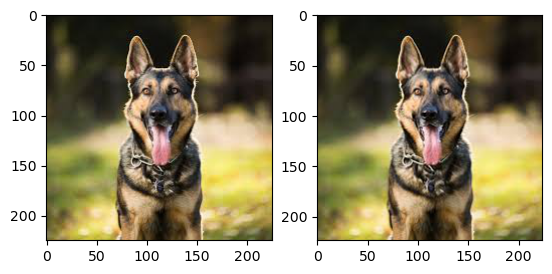

In [15]:
plt.subplot(1,2,1)
plt.imshow(img)

plt.subplot(1,2,2)
plt.imshow(processed)

In [25]:
#step3:convert Image->Numpy&Normalize
img_array=np.array(processed).astype(np.float32)/255.0

In [26]:
#step4:flatten Image Pixels
flat_pixels=img_array.reshape(-1,3) #-1 tells Python to row automatically

In [27]:
#step5:create pandas Dataframe
df=pd.DataFrame(flat_pixels,columns=["R","G","B"])

In [28]:
#step6:Display OutPut
print(df.head())
print("\nDataFrame Shape:",df.shape)

          R         G         B
0  0.058824  0.062745  0.043137
1  0.058824  0.062745  0.043137
2  0.058824  0.062745  0.043137
3  0.058824  0.062745  0.043137
4  0.058824  0.062745  0.039216

DataFrame Shape: (50176, 3)


# Multiple Images

In [29]:
import os

In [31]:
#step2:upload folder
img_folder=(r"C:\Users\vinod\OneDrive\Documents\Images")

In [32]:
#create dataframe
data=[]

In [38]:
#step:4 loop through images
for img_name in os.listdir(img_folder):
    if img_name.lower().endswith((".jpg",".png",".jpeg")):
        img_path=os.path.join(img_folder,img_name)

        #load and preproceesing image
        img=Image.open(img_path).convert("RGB").resize((224,224))
        img_array=np.array(img).astype(np.float32)/255.0

       #flatten pixels
        flat_pixels=img_array.reshape(-1,3)

        #Store each pixels as a row
        for pixels in flat_pixels:
            data.append([img_name,pixels[0],pixels[1],pixels[2]])

In [39]:
#create DataFrame
df=pd.DataFrame(data,columns=["image_name","R","G","B"])


In [41]:
# display output
print(df.head())
print(df.shape)

          image_name         R         G         B
0  1762923068667.jpg  0.635294  0.662745  0.686275
1  1762923068667.jpg  0.639216  0.662745  0.686275
2  1762923068667.jpg  0.647059  0.666667  0.686275
3  1762923068667.jpg  0.647059  0.666667  0.682353
4  1762923068667.jpg  0.650980  0.670588  0.682353
(1806336, 4)


In [42]:
df

,image_name,R,G,B
0,1762923068667.jpg,0.635294,0.662745,0.686275
1,1762923068667.jpg,0.639216,0.662745,0.686275
2,1762923068667.jpg,0.647059,0.666667,0.686275
3,1762923068667.jpg,0.647059,0.666667,0.682353
4,1762923068667.jpg,0.650980,0.670588,0.682353
...,...,...,...,...
1806331,IMG_20251220_144855.jpg,0.870588,0.823529,0.756863
1806332,IMG_20251220_144855.jpg,0.886275,0.850980,0.796078
1806333,IMG_20251220_144855.jpg,0.960784,0.933333,0.898039
1806334,IMG_20251220_144855.jpg,0.968627,0.945098,0.925490
